# Clustering aplicado a dados de energia

Neste notebook, vamos agrupar consumidores com características semelhantes usando **K-Means**.

1. **Exemplo resolvido em Python:** consumo mensal e demanda máxima.
2. **Exercício proposto em Python:** acrescentar o percentual de consumo noturno.
3. **Exercício no Orange Data Mining:** analisar a mesma base do exercício proposto.

Os dados são **simulados para fins didáticos**. Cada linha representa um consumidor no mesmo mês de observação. Não há classes previamente informadas: os grupos serão construídos a partir dos atributos numéricos.

**Como usar:** abra no Google Colab ou Jupyter e execute as células na ordem. As bases estão incluídas no notebook; não é necessário cadastrar-se em um serviço ou baixar dados externos. As células com comentários “Sua implementação” devem ser completadas pelo aluno.

## 1. Exemplo resolvido — perfis de consumo

Uma empresa de energia deseja identificar perfis de consumidores para planejar ações de acompanhamento. Vamos agrupar 30 consumidores a partir de duas medidas.

| Atributo | Significado | Papel |
| --- | --- | --- |
| `consumidor` | Código que identifica a unidade consumidora. | Identificação; não entra no K-Means. |
| `consumo_mensal_kwh` | Energia elétrica consumida no mês, em kWh. | Entrada numérica. |
| `demanda_maxima_kw` | Maior potência média demandada em um intervalo de medição de 15 minutos no mês, em kW. | Entrada numérica. |

Consumo em kWh representa **energia acumulada**. Demanda em kW representa **potência**. Duas unidades com consumo mensal semelhante podem apresentar demandas máximas diferentes.

O K-Means aproxima consumidores pelas distâncias entre seus atributos. O parâmetro **k** define quantos grupos serão formados; precisamos justificar essa escolha.

### Como o K-Means constrói os grupos

Um **cluster** é um conjunto de consumidores próximos no espaço dos atributos usados. Essa proximidade depende das medidas selecionadas; um grupo semelhante em consumo não necessariamente terá o mesmo horário de uso.

O **k** é a quantidade de grupos solicitada. Com k = 2, o algoritmo cria dois grupos; com k = 3, cria três. Ele não descobre essa quantidade sozinho.

Depois de escolher k, o K-Means:

1. Define centros iniciais para os grupos.
2. Atribui cada consumidor ao centro mais próximo.
3. Recalcula cada centro usando as médias dos integrantes do grupo.
4. Repete as atribuições e atualizações até convergir ou atingir o limite de iterações.

Esses centros são os **centroides**. Na implementação usual, a proximidade é medida pela distância euclidiana: a distância em linha reta no espaço dos atributos padronizados.

**Exemplo no contexto de energia:** consumidores de menor consumo e menor demanda podem ficar próximos entre si. Outros, com maior consumo e maior demanda, podem formar outro perfil. São os valores das medidas que determinam a proximidade; não fornecemos nomes de perfis ao modelo.

### 1.1. Importar as bibliotecas
Pandas organiza a tabela; Matplotlib cria os gráficos. Usaremos `StandardScaler` para padronizar os atributos, `KMeans` para agrupar e `silhouette_score` para avaliar a separação dos grupos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### 1.2. Carregar a base
Os valores abaixo já estão preparados. Nesta etapa, estamos apenas criando a tabela de consumidores.

In [2]:
dados_resolvido = {'consumidor': ['UC01', 'UC02', 'UC03', 'UC04', 'UC05', 'UC06', 'UC07', 'UC08', 'UC09', 'UC10',
                'UC11', 'UC12', 'UC13', 'UC14', 'UC15', 'UC16', 'UC17', 'UC18', 'UC19', 'UC20',
                'UC21', 'UC22', 'UC23', 'UC24', 'UC25', 'UC26', 'UC27', 'UC28', 'UC29',
                'UC30'],
 'consumo_mensal_kwh': [190.33, 125.37, 831.37, 454.23, 437.25, 181.85, 179.53, 183.58, 405.66,
                        204.62, 188.53, 853.27, 204.6, 869.01, 479.97, 201.01, 874.4, 858.1,
                        870.81, 408.01, 431.56, 836.83, 414.82, 825.76, 434.9, 809.2, 193.09,
                        416.81, 396.91, 842.3],
 'demanda_maxima_kw': [2.02, 1.85, 11.62, 5.72, 6.36, 3.06, 2.07, 2.34, 5.39, 2.89, 1.98,
                       11.61, 2.48, 11.53, 5.6, 2.97, 11.61, 11.82, 11.77, 5.62, 6.02, 11.18,
                       5.46, 11.98, 5.98, 11.34, 2.07, 5.38, 6.13, 12.25]}

df = pd.DataFrame(dados_resolvido)

In [3]:
df.head()

,consumidor,consumo_mensal_kwh,demanda_maxima_kw
0,UC01,190.33,2.02
1,UC02,125.37,1.85
2,UC03,831.37,11.62
3,UC04,454.23,5.72
4,UC05,437.25,6.36


### 1.3. Conferir os dados
Antes do agrupamento, confira a quantidade de linhas, os tipos das colunas e a existência de valores ausentes. Se houvesse dados faltantes ou registros inconsistentes, seria necessário tratá-los antes de continuar.

In [4]:
df.shape

(30, 3)

In [5]:
df.dtypes

consumidor                str
consumo_mensal_kwh    float64
demanda_maxima_kw     float64
dtype: object

In [6]:
df.isna().sum()

consumidor            0
consumo_mensal_kwh    0
demanda_maxima_kw     0
dtype: int64

In [7]:
df[['consumo_mensal_kwh', 'demanda_maxima_kw']].describe().round(2)

,consumo_mensal_kwh,demanda_maxima_kw
count,30.00,30.00
mean,486.79,6.60
std,278.96,3.92
min,125.37,1.85
25%,201.91,2.91
50%,424.18,5.67
75%,829.97,11.48
max,874.40,12.25


### 1.4. Observar os consumidores antes do agrupamento
Cada ponto representa um consumidor. Ainda não atribuímos nenhum cluster.

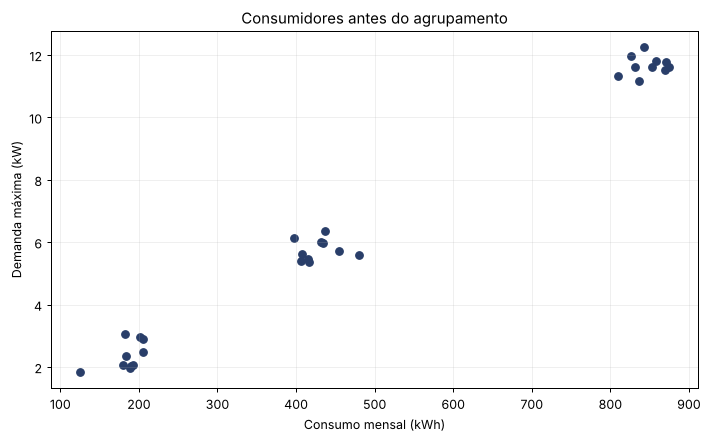

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df['consumo_mensal_kwh'], df['demanda_maxima_kw'], color='#293E69')
plt.xlabel('Consumo mensal (kWh)')
plt.ylabel('Demanda máxima (kW)')
plt.title('Consumidores antes do agrupamento')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 1.5. Selecionar os atributos
Criamos `X` apenas com as entradas numéricas. O código do consumidor não representa uma medida de consumo; por isso, fica fora do cálculo das distâncias.

In [9]:
atributos = ['consumo_mensal_kwh', 'demanda_maxima_kw']
X = df[atributos].copy()

In [10]:
X.head()

,consumo_mensal_kwh,demanda_maxima_kw
0,190.33,2.02
1,125.37,1.85
2,831.37,11.62
3,454.23,5.72
4,437.25,6.36


### 1.6. Padronizar as escalas

O K-Means calcula distâncias usando os valores das colunas. Imagine dois consumidores com diferença de **200 kWh** no consumo e de **2 kW** na demanda: os números do consumo são muito maiores, embora as unidades sejam diferentes. Sem ajustar as escalas, o consumo pode dominar as distâncias.

O `StandardScaler` transforma cada valor desta forma:

$$z = \frac{x - \text{média da coluna}}{\text{desvio padrão da coluna}}$$

Depois da transformação, cada coluna tem média próxima de zero e desvio padrão igual a 1 nesta base. Assim, compararemos os atributos em escalas semelhantes.

**Como interpretar:** um valor padronizado negativo está abaixo da média; um positivo está acima. Isso não significa consumo negativo. A transformação também não coloca os valores obrigatoriamente entre 0 e 1.

Usaremos `X_padronizado` para o K-Means e para o Silhouette Score. Os gráficos de perfis e as tabelas de médias usarão os dados originais, em kWh e kW.

In [11]:
padronizador = StandardScaler()
X_padronizado = padronizador.fit_transform(X)

In [12]:
pd.DataFrame(X_padronizado, columns=atributos).head().round(2)

,consumo_mensal_kwh,demanda_maxima_kw
0,-1.08,-1.19
1,-1.32,-1.23
2,1.26,1.30
3,-0.12,-0.23
4,-0.18,-0.06


### 1.7. Entender inércia, distorções e diferentes valores de k

**Inércia** mede quanto os consumidores estão espalhados em torno do centro de seus próprios grupos. Para calculá-la, o K-Means:

1. Mede a distância de cada consumidor ao centroide do seu cluster.
2. Eleva cada distância ao quadrado.
3. Soma esses valores para todos os consumidores.

Se os consumidores ficam próximos dos centroides, a inércia é menor. Um ponto muito distante contribui mais para a soma, porque a distância é elevada ao quadrado.

**No cenário de energia:** colocar consumidores de 180 kWh e 850 kWh no mesmo grupo tende a aumentar a dispersão. Ao separá-los em perfis diferentes, os consumidores podem ficar mais próximos dos centros de seus respectivos grupos.

Vamos testar **k de 1 a 8**. Cada passagem do `for` ajusta um modelo completo com uma quantidade diferente de grupos. `modelo_teste.inertia_` fornece a inércia dessa solução. Como as entradas estão padronizadas, essa inércia não é uma quantidade de kWh nem um valor monetário.

**Por que não escolher simplesmente a menor inércia?** Ao aumentar k, podemos reduzir a dispersão criando grupos menores. No extremo de um grupo por consumidor, a inércia seria zero, mas já não teríamos uma síntese útil dos perfis. Precisamos avaliar quanto ganhamos ao adicionar um grupo.

**E o que são distorções?** No exemplo anexo, a lista `distorcoes` recebe `modelo.inertia_`. Portanto, nesse código, “distorção” é o nome usado para a **mesma soma de distâncias ao quadrado** que chamamos de inércia. A lista reúne um valor dessa medida para cada k testado; não representa outra métrica. Aqui usamos o nome `inercias` para deixar explícita a ligação com `inertia_`.

### Uma conta simples: dos consumidores à inércia

Considere apenas três consumos: **100, 120 e 140 kWh**, todos no mesmo cluster. Para facilitar a conta, este exemplo usa somente consumo, sem padronização. O centroide é a média: **120 kWh**.

| Consumo | Distância ao centroide | Distância ao quadrado |
| --- | --- | --- |
| 100 kWh | 20 kWh | 400 kWh² |
| 120 kWh | 0 kWh | 0 kWh² |
| 140 kWh | 20 kWh | 400 kWh² |

A inércia desse agrupamento é **400 + 0 + 400 = 800 kWh²**. Ela não é consumo de energia: é uma medida de dispersão. A distância ao quadrado faz consumidores muito afastados contribuírem mais para o valor total.

Se criarmos dois grupos, um com 100 kWh e outro com 120 e 140 kWh, seus centroides serão 100 e 130 kWh. A soma passa a ser **0² + 10² + 10² = 200 kWh²**. Com um grupo para cada consumidor, ela chega a zero.

| Quantidade de grupos | Inércia no exemplo | Leitura |
| --- | --- | --- |
| 1 | 800 kWh² | Os três consumidores compartilham um centro. |
| 2 | 200 kWh² | A separação reduz as distâncias aos próprios centros. |
| 3 | 0 kWh² | Cada consumidor tem seu próprio centro. |

Isso explica por que **a menor inércia, sozinha, não determina o melhor k**: podemos reduzi-la criando mais grupos, até perder a utilidade de resumir os consumidores em perfis. O Elbow procura onde o ganho adicional fica menos expressivo; o Silhouette Score acrescenta a avaliação de separação.

No notebook, as distâncias usam todas as entradas padronizadas. Assim, os valores de inércia dos gráficos não têm unidade de kWh². Só compare inércias calculadas com a mesma base, os mesmos atributos e o mesmo tratamento de escala.

In [13]:
valores_k = range(1, 9)
inercias = []

for k in valores_k:
    modelo_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo_teste.fit(X_padronizado)
    inercias.append(modelo_teste.inertia_)

### 1.8. Método Elbow — como ler a curva do cotovelo

O **Elbow** procura uma quantidade de grupos que reduza bastante a dispersão sem fragmentar demais os consumidores. Seu nome vem da aparência de um “cotovelo” na curva: primeiro há uma queda forte; depois a curva fica mais horizontal.

**Leitura do gráfico:**

- **Eixo X:** quantidade de clusters, k.
- **Eixo Y:** inércia obtida para cada k.
- **Queda forte:** o grupo adicional ajuda bastante a tornar os clusters mais compactos.
- **Queda pequena:** o grupo adicional traz um ganho menor.

Leia da esquerda para a direita. Procure o ponto **em que começa a redução mais lenta**, depois das quedas mais expressivas.

Nesta base, os valores aproximados são:

| k | Inércia | O que observar |
| --- | --- | --- |
| 1 | 60,00 | Todos os consumidores estão juntos. |
| 2 | 8,23 | Há uma grande redução na dispersão. |
| 3 | 0,44 | A dispersão ainda cai bastante. |
| 4 | 0,33 | O ganho adicional é pequeno, comparado às quedas anteriores. |

Ao passar de 2 para 3 grupos, a inércia cai aproximadamente **7,78**. De 3 para 4, cai apenas **0,12**. Isso sugere um cotovelo próximo de **k = 3**.

**Atenção:** o Elbow é uma indicação visual. Nem toda curva apresenta um cotovelo evidente; ele não garante uma quantidade “verdadeira” de grupos. Vamos combinar essa leitura com o Silhouette Score e com os perfis encontrados.

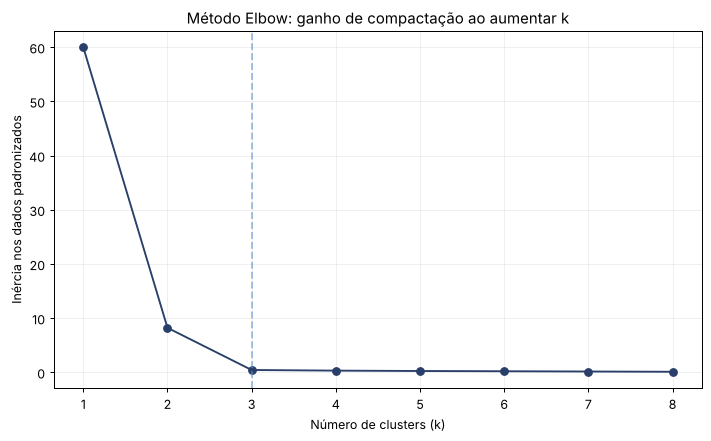

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(list(valores_k), inercias, 'o-', color='#293E69')
plt.xticks(list(valores_k))
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia nos dados padronizados')
plt.title('Método Elbow: ganho de compactação ao aumentar k')
plt.axvline(3, color='#5B94D3', linestyle='--', alpha=0.6)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 1.9. Silhouette Score — o consumidor combina com seu grupo?

O **Silhouette Score** avalia se os consumidores estão próximos dos integrantes do próprio grupo e separados dos integrantes dos outros grupos. A pergunta é: **“este consumidor se parece mais com seu grupo ou com um grupo vizinho?”**

Para cada consumidor, o cálculo compara duas distâncias:

- **a:** distância média aos outros consumidores do próprio cluster.
- **b:** para cada outro cluster, calcula-se a distância média aos seus integrantes; b é a menor dessas médias, correspondente ao grupo alternativo mais próximo.

Aqui usamos distâncias entre **consumidores**, calculadas com as entradas padronizadas. Não são distâncias aos centroides.

O coeficiente de cada consumidor é:

$$s = \frac{b-a}{\max(a,b)}$$

Se a é muito menor que b, o consumidor está mais próximo do seu grupo e s fica próximo de 1. Se a e b são parecidos, ele está próximo da fronteira e s fica próximo de zero. Se a é maior que b, s fica negativo: ele pode combinar melhor com outro grupo.

**Exemplo numérico ilustrativo:** se a = 0,2 e b = 1,0, então s = (1,0 − 0,2) / 1,0 = **0,8**. Se a = 0,8 e b = 0,4, então s = (0,4 − 0,8) / 0,8 = **−0,5**. São distâncias ilustrativas no espaço padronizado, não valores de energia.

`silhouette_score` retorna a **média dos coeficientes de todos os consumidores**. O resultado varia de −1 a 1:

| Valor | Interpretação |
| --- | --- |
| Próximo de 1 | Em média, consumidores próximos do próprio grupo e afastados dos grupos vizinhos. |
| Próximo de 0 | Há sobreposição ou pouca separação entre os grupos. |
| Negativo | Em média, há consumidores mais próximos de grupos alternativos do que do próprio grupo. |

**Como comparar:** nesta mesma base, com os mesmos atributos e a mesma padronização, valores maiores indicam melhor separação média. Uma média alta ainda pode esconder alguns consumidores mal agrupados.

**Não é acurácia:** 0,80 não significa “80% de acertos”. Não temos classes corretas informadas para fazer essa comparação. Também não há um corte universal, como 0,50, que torne todo agrupamento adequado ao seu contexto.

O cálculo exige pelo menos dois clusters e menos clusters do que amostras. Por isso, vamos testar **k de 2 a 8**, sem calcular para k = 1.

In [15]:
# Um score médio para cada k, calculado na mesma escala do agrupamento.
scores_silhouette = []

for k in range(2, 9):
    modelo_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    rotulos = modelo_teste.fit_predict(X_padronizado)
    nota = silhouette_score(X_padronizado, rotulos)
    scores_silhouette.append(nota)

In [16]:
comparacao = pd.DataFrame({
    'k': list(range(2, 9)),
    'inercia': inercias[1:],
    'silhouette_score': scores_silhouette
})
comparacao.round(4)

,k,inercia,silhouette_score
0,2,8.2292,0.7963
1,3,0.4445,0.8871
2,4,0.3281,0.7710
3,5,0.2578,0.6231
4,6,0.2118,0.6690
5,7,0.1650,0.6827
6,8,0.1158,0.4860


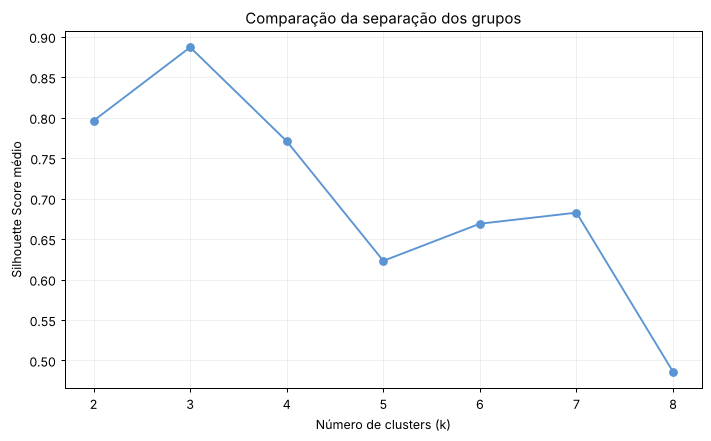

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(comparacao['k'], comparacao['silhouette_score'], 'o-', color='#5B94D3')
plt.xticks(comparacao['k'])
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score médio')
plt.title('Comparação da separação dos grupos')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 1.10. Combinar Elbow e Silhouette Score para escolher k

As duas análises respondem a perguntas complementares:

| Análise | Pergunta | Evidência nesta base |
| --- | --- | --- |
| Elbow | A partir de qual k o ganho em compactação fica menor? | O cotovelo aparece próximo de 3 grupos. |
| Silhouette Score | Qual k apresenta melhor separação média? | k = 3 apresenta aproximadamente 0,887, acima dos demais valores testados. |
| Interpretação dos perfis | Os grupos ajudam a compreender os consumidores? | Os três perfis distinguem intensidades de consumo e demanda. |

Vamos adotar **k = 3**. O valor de Silhouette Score próximo de 0,887 descreve a separação nesta base simulada; não representa 88,7% de acertos nem comprova eficiência energética.

**Em outra base:** se o maior Silhouette Score ocorrer em um k diferente do cotovelo, examine os tamanhos e as características dos grupos. Compare as alternativas e justifique a escolha; não há obrigação de os dois critérios coincidirem.

**Parâmetros usados no código:**

- `n_clusters=3`: pede ao algoritmo que forme três grupos.
- `random_state=42`: fixa a aleatoriedade para repetir o resultado com os mesmos dados e configuração. O número 42 é apenas uma escolha de semente.
- `n_init=10`: executa dez inicializações com centros de partida diferentes e conserva a solução com menor inércia. Cada inicialização pode envolver várias rodadas de atribuição e atualização dos centroides.
- `fit_predict(X_padronizado)`: ajusta o modelo à base e devolve o número do cluster de cada consumidor.

In [18]:
k_escolhido = 3
modelo = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
clusters = modelo.fit_predict(X_padronizado)

### 1.11. Acrescentar os grupos à tabela original
Os números 0, 1 e 2 são apenas identificadores dos grupos: não indicam ordem, qualidade ou intensidade de consumo.

In [19]:
resultado = df.copy()
resultado['cluster'] = clusters

In [20]:
resultado.head(10)

,consumidor,consumo_mensal_kwh,demanda_maxima_kw,cluster
0,UC01,190.33,2.02,1
1,UC02,125.37,1.85,1
2,UC03,831.37,11.62,0
3,UC04,454.23,5.72,2
4,UC05,437.25,6.36,2
5,UC06,181.85,3.06,1
6,UC07,179.53,2.07,1
7,UC08,183.58,2.34,1
8,UC09,405.66,5.39,2
9,UC10,204.62,2.89,1


### 1.12. Avaliar o modelo final com Silhouette Score

Na chamada `silhouette_score(X_padronizado, clusters)`:

- `X_padronizado` fornece as medidas que serão usadas para calcular as distâncias.
- `clusters` informa a qual grupo pertence cada consumidor.

Não colocamos `cluster` dentro das entradas: o número do grupo é um resultado do algoritmo, não uma medida do consumidor. Incluí-lo nas distâncias faria a avaliação depender artificialmente dos próprios rótulos.

Também mantemos a padronização usada no treinamento. Calcular o score nos dados originais daria outro peso a kWh e kW, avaliando uma geometria diferente daquela usada pelo K-Means.

In [21]:
nota_final = silhouette_score(X_padronizado, clusters)
print(f'Silhouette Score do modelo com k = {k_escolhido}: {nota_final:.4f}')

Silhouette Score do modelo com k = 3: 0.8871


### 1.13. Entender e visualizar os centroides

O **centroide** reúne a média de cada atributo dos consumidores de um cluster. Se três consumidores têm consumos de 180, 200 e 220 kWh e demandas de 2, 3 e 4 kW, o centroide desse grupo é **(200 kWh, 3 kW)**.

Ele representa o centro do perfil, mas não precisa corresponder a um consumidor real. No gráfico, cada ponto é um consumidor e cada **X preto** marca um centroide.

O modelo guarda os centroides na escala padronizada. `inverse_transform` desfaz essa transformação para que possamos ler os centros em kWh e kW. As tabelas de médias originais ajudam a descrever cada perfil.

In [22]:
centroides = pd.DataFrame(
    padronizador.inverse_transform(modelo.cluster_centers_),
    columns=atributos
)
centroides.index.name = 'cluster'
centroides.round(2)

,consumo_mensal_kwh,demanda_maxima_kw
cluster,,
0,847.10,11.67
1,185.25,2.37
2,428.01,5.77


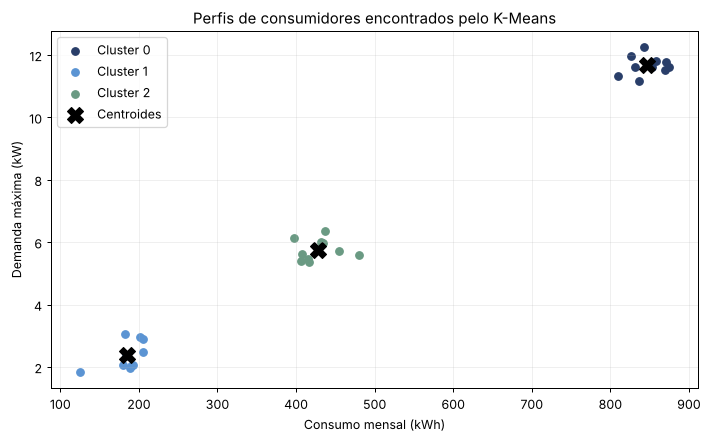

In [23]:
cores = ['#293E69', '#5B94D3', '#6A9A83']
plt.figure(figsize=(8, 5))

for cluster in range(k_escolhido):
    grupo = resultado[resultado['cluster'] == cluster]
    plt.scatter(grupo['consumo_mensal_kwh'], grupo['demanda_maxima_kw'],
                color=cores[cluster], label=f'Cluster {cluster}')

plt.scatter(centroides['consumo_mensal_kwh'], centroides['demanda_maxima_kw'],
            marker='X', s=160, color='black', label='Centroides')
plt.xlabel('Consumo mensal (kWh)')
plt.ylabel('Demanda máxima (kW)')
plt.title('Perfis de consumidores encontrados pelo K-Means')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 1.14. Interpretar os perfis
Vamos resumir a quantidade de consumidores e as médias de consumo e demanda de cada grupo. A ordenação abaixo facilita a leitura; ela não muda os números dos clusters.

In [24]:
resumo = resultado.groupby('cluster').agg(
    consumidores=('consumidor', 'count'),
    consumo_medio_kwh=('consumo_mensal_kwh', 'mean'),
    demanda_media_kw=('demanda_maxima_kw', 'mean')
)
resumo.sort_values('consumo_medio_kwh').round(2)

,consumidores,consumo_medio_kwh,demanda_media_kw
cluster,,,
1,10,185.25,2.37
2,10,428.01,5.77
0,10,847.10,11.67


**Interpretação do exemplo:** aparecem perfis de menor, intermediário e maior consumo, acompanhados por demandas máximas crescentes. Compare as médias para identificar qual número de cluster corresponde a cada perfil.

A empresa poderia acompanhar mais de perto o grupo com maior demanda para investigar oportunidades de distribuir o uso dos equipamentos ao longo do dia. Essa é uma hipótese de ação: os dados não informam os equipamentos utilizados nem demonstram desperdício ou eficiência.

O resultado descreve similaridades nesta base. Não usamos uma coluna de classe, acurácia ou divisão treino/teste, pois esta atividade é uma análise exploratória dos consumidores disponíveis.

### 1.15. Conferência de aprendizagem

1. Por que `consumidor` ficou fora de `X`?
2. Por que padronizamos kWh e kW antes de agrupar?
3. Por que escolher o k de menor inércia pode criar grupos demais?
4. Na curva Elbow, o que a mudança de inclinação indica?
5. Um Silhouette Score de 0,80 significa 80% de acertos? Explique.
6. Qual foi a evidência para escolher três grupos nesta base?
7. Uma boa separação entre os grupos comprova desperdício de energia? Justifique.

## 2. Exercício proposto — consumo e horário de uso

Uma empresa quer agrupar **60 consumidores** para entender diferenças na intensidade e no horário de uso da energia. Além do consumo mensal e da demanda máxima, ela registrou o percentual da energia mensal consumida entre **22h e 6h**.

Sua tarefa é construir os grupos, justificar a quantidade escolhida e explicar o perfil de cada um. A nova base também é simulada, não possui classes e não contém resultados de clustering.

| Atributo | Significado | Papel |
| --- | --- | --- |
| `consumidor` | Identificador da unidade consumidora. | Identificação. |
| `consumo_mensal_kwh` | Energia consumida no mês, em kWh. | Entrada. |
| `demanda_maxima_kw` | Maior potência média em intervalos de 15 minutos no mês, em kW. | Entrada. |
| `consumo_noturno_pct` | Percentual do consumo mensal ocorrido entre 22h e 6h. Ex.: 60 significa 60% da energia do mês. | Entrada. |

**Use os três atributos numéricos.** Não utilize o identificador como entrada e não copie o valor de k do exemplo resolvido sem analisar a nova base.

### 2.1. Carregar a nova base — código fornecido
Execute esta célula. Os dados estão incluídos para que a atividade funcione mesmo sem o arquivo CSV separado.

In [25]:
csv_proposto = '''
consumidor,consumo_mensal_kwh,demanda_maxima_kw,consumo_noturno_pct
UC001,761.8,10.74,64.16
UC002,245.99,2.9,17.82
UC003,521.91,7.5,42.4
UC004,218.13,3.58,9.64
UC005,1028.53,11.63,39.11
UC006,467.4,7.17,75.0
UC007,453.99,6.71,68.82
UC008,243.99,2.79,17.73
UC009,1181.46,11.09,41.69
UC010,521.92,5.61,28.52
UC011,505.72,7.31,73.54
UC012,500.72,5.56,7.08
UC013,396.27,5.88,21.62
UC014,406.46,5.54,24.19
UC015,788.29,11.79,47.84
UC016,491.68,6.06,69.71
UC017,508.57,7.39,72.63
UC018,215.18,3.16,9.88
UC019,422.59,5.51,73.21
UC020,238.14,3.21,29.61
UC021,928.14,12.77,67.66
UC022,804.13,11.18,61.53
UC023,443.74,7.58,16.25
UC024,414.75,7.56,84.07
UC025,448.01,5.6,19.27
UC026,497.84,7.15,13.68
UC027,245.63,3.5,19.41
UC028,872.35,11.45,44.15
UC029,275.47,3.04,24.43
UC030,568.4,6.28,28.88
UC031,471.62,7.04,62.72
UC032,455.04,5.43,15.24
UC033,574.47,6.53,63.43
UC034,213.57,3.21,22.88
UC035,576.85,6.51,71.17
UC036,245.2,3.31,16.44
UC037,493.39,5.67,19.09
UC038,197.32,3.11,14.3
UC039,950.74,14.57,36.12
UC040,179.35,2.6,14.02
UC041,897.92,13.43,48.91
UC042,216.64,2.66,22.92
UC043,525.42,4.96,71.66
UC044,480.13,6.13,82.23
UC045,941.82,12.71,35.24
UC046,443.62,5.55,65.85
UC047,179.39,3.23,16.82
UC048,886.15,12.34,32.63
UC049,1088.92,11.48,42.41
UC050,726.74,12.3,35.44
UC051,429.11,5.77,76.5
UC052,487.85,6.1,14.75
UC053,411.17,6.61,20.44
UC054,499.25,6.1,21.71
UC055,906.09,11.66,42.99
UC056,221.62,2.74,21.08
UC057,237.7,3.81,25.01
UC058,449.4,6.11,29.46
UC059,1010.25,13.15,57.04
UC060,468.3,6.4,70.86
'''

df_proposto = pd.read_csv(StringIO(csv_proposto))

In [26]:
df_proposto.head()

,consumidor,consumo_mensal_kwh,demanda_maxima_kw,consumo_noturno_pct
0,UC001,761.80,10.74,64.16
1,UC002,245.99,2.90,17.82
2,UC003,521.91,7.50,42.40
3,UC004,218.13,3.58,9.64
4,UC005,1028.53,11.63,39.11


### 2.2. Conferir a base e selecionar as entradas
Confira dimensões, tipos, ausentes e estatísticas. Crie `X_proposto` com as três entradas numéricas.

In [27]:
# Conferência da base
print('Linhas e colunas:', df_proposto.shape)
print()
print(df_proposto.dtypes)
print()
print('Valores ausentes por coluna:')
print(df_proposto.isna().sum())
print()
print('Consumidores duplicados:', df_proposto['consumidor'].duplicated().sum())
df_proposto.describe().round(2)

Linhas e colunas: (60, 4)

consumidor                 str
consumo_mensal_kwh     float64
demanda_maxima_kw      float64
consumo_noturno_pct    float64
dtype: object

Valores ausentes por coluna:
consumidor             0
consumo_mensal_kwh     0
demanda_maxima_kw      0
consumo_noturno_pct    0
dtype: int64

Consumidores duplicados: 0


,consumo_mensal_kwh,demanda_maxima_kw,consumo_noturno_pct
count,60.00,60.00,60.00
mean,524.70,6.97,39.71
std,261.37,3.37,23.16
min,179.35,2.60,7.08
25%,366.07,4.67,19.38
50%,475.88,6.12,33.94
75%,614.32,8.37,63.61
max,1181.46,14.57,84.07


In [28]:
atributos_proposto = ['consumo_mensal_kwh', 'demanda_maxima_kw', 'consumo_noturno_pct']
X_proposto = df_proposto[atributos_proposto].copy()   # 'consumidor' fica fora: é só identificação
X_proposto.head()

,consumo_mensal_kwh,demanda_maxima_kw,consumo_noturno_pct
0,761.80,10.74,64.16
1,245.99,2.90,17.82
2,521.91,7.50,42.40
3,218.13,3.58,9.64
4,1028.53,11.63,39.11


### 2.3. Padronizar os atributos
Crie um novo `StandardScaler` e transforme `X_proposto`. Não reutilize o padronizador ajustado no exemplo anterior.

In [29]:
padronizador_proposto = StandardScaler()
X_proposto_padronizado = padronizador_proposto.fit_transform(X_proposto)

pd.DataFrame(X_proposto_padronizado, columns=atributos_proposto).describe().round(2)

,consumo_mensal_kwh,demanda_maxima_kw,consumo_noturno_pct
count,60.00,60.00,60.00
mean,-0.00,0.00,0.00
std,1.01,1.01,1.01
min,-1.33,-1.31,-1.42
25%,-0.61,-0.69,-0.89
50%,-0.19,-0.26,-0.25
75%,0.35,0.42,1.04
max,2.53,2.27,1.93


### 2.4. Investigar a quantidade de grupos

Calcule a inércia para **k de 1 a 8** e o Silhouette Score para **k de 2 a 8**. Use `random_state=42` e `n_init=10`.

Construa a curva Elbow e o gráfico de Silhouette Score em células separadas. Monte também uma tabela com k, inércia e Silhouette Score.

Ao analisar a curva Elbow, procure a mudança de inclinação, não apenas a menor inércia. Ao comparar os scores, procure os maiores valores e observe se os perfis resultantes são úteis para a análise de energia.

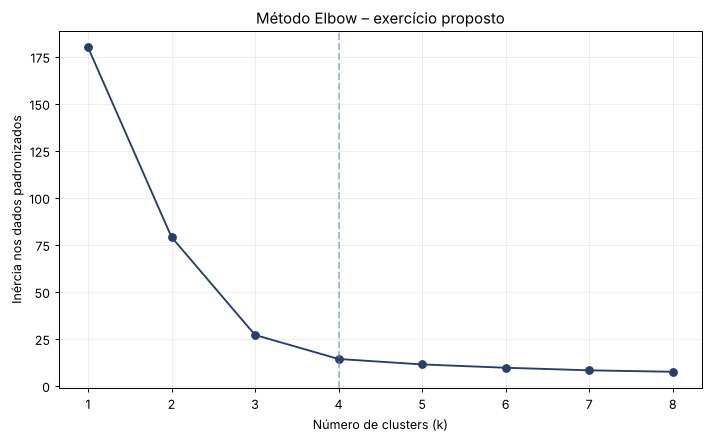

In [30]:
valores_k_proposto = range(1, 9)
inercias_proposto = []

for k in valores_k_proposto:
    modelo_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo_teste.fit(X_proposto_padronizado)
    inercias_proposto.append(modelo_teste.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(valores_k_proposto), inercias_proposto, 'o-', color='#293E69')
plt.xticks(list(valores_k_proposto))
plt.axvline(4, color='#5B94D3', linestyle='--', alpha=0.6)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia nos dados padronizados')
plt.title('Método Elbow – exercício proposto')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('imagens/elbow_proposto.png', dpi=120)
plt.show()

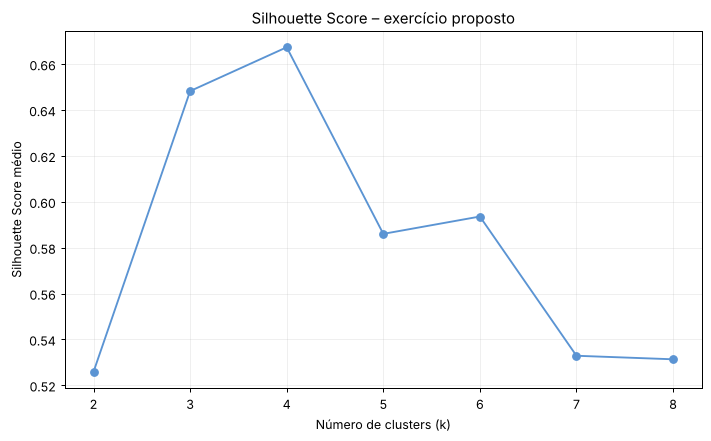

In [31]:
scores_proposto = []

for k in range(2, 9):
    modelo_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    rotulos = modelo_teste.fit_predict(X_proposto_padronizado)
    scores_proposto.append(silhouette_score(X_proposto_padronizado, rotulos))

plt.figure(figsize=(8, 5))
plt.plot(list(range(2, 9)), scores_proposto, 'o-', color='#5B94D3')
plt.xticks(list(range(2, 9)))
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score médio')
plt.title('Silhouette Score – exercício proposto')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('imagens/silhouette_proposto.png', dpi=120)
plt.show()

In [32]:
comparacao_proposto = pd.DataFrame({
    'k': list(range(2, 9)),
    'inercia': inercias_proposto[1:],
    'silhouette_score': scores_proposto,
})
comparacao_proposto['queda_da_inercia'] = -comparacao_proposto['inercia'].diff()
comparacao_proposto.loc[0, 'queda_da_inercia'] = inercias_proposto[0] - inercias_proposto[1]
comparacao_proposto.round(4)

,k,inercia,silhouette_score,queda_da_inercia
0,2,79.0912,0.5259,100.9088
1,3,27.0580,0.6483,52.0333
2,4,14.2800,0.6674,12.7779
3,5,11.3885,0.5860,2.8916
4,6,9.6278,0.5936,1.7607
5,7,8.2584,0.5329,1.3694
6,8,7.4846,0.5314,0.7738


### 2.5. Justificar k e construir o modelo final

Escolha k considerando a curva Elbow, o Silhouette Score e a interpretação dos perfis. Se os critérios sugerirem escolhas diferentes, explique sua decisão. Treine o modelo e adicione os rótulos a uma cópia da base original.

Na justificativa, cite o ponto de mudança da curva, compare os scores das alternativas e explique o que os grupos escolhidos permitem compreender.

**Justificativa de k:** escolhemos **k = 4**.

- **Elbow:** a inércia cai de 180,0 (k = 1) para 79,1 (k = 2), 27,1 (k = 3) e 14,3 (k = 4). A partir daí as quedas ficam pequenas: de 4 para 5 grupos a inércia cai só cerca de 2,9, contra cerca de 12,8 de 3 para 4. A mudança de inclinação, o cotovelo, fica em **k = 4**.
- **Silhouette Score:** o maior valor entre os k testados é o de **k = 4 (≈ 0,667)**, acima de k = 3 (≈ 0,648) e de k = 5 (≈ 0,586).
- **Perfis:** com k = 3, consumidores de consumo médio que usam energia de dia e de noite ficam misturados com os de baixo consumo. Com k = 4, o grupo de consumo intermediário (≈ 480 kWh, ≈ 6 kW) se divide em dois perfis com **horários de uso diferentes**, justamente a informação que o percentual noturno acrescenta. Com k = 5, surge um grupo com só 4 consumidores, separado do grupo de alto consumo, sem ganho de interpretação e com Silhouette menor.

Os dois critérios e a interpretação dos perfis apontam para o mesmo valor.

In [33]:
k_proposto = 4
modelo_proposto = KMeans(n_clusters=k_proposto, random_state=42, n_init=10)
clusters_proposto = modelo_proposto.fit_predict(X_proposto_padronizado)

resultado_proposto = df_proposto.copy()
resultado_proposto['cluster'] = clusters_proposto
resultado_proposto.head(10)

,consumidor,consumo_mensal_kwh,demanda_maxima_kw,consumo_noturno_pct,cluster
0,UC001,761.80,10.74,64.16,1
1,UC002,245.99,2.90,17.82,0
2,UC003,521.91,7.50,42.40,3
3,UC004,218.13,3.58,9.64,0
4,UC005,1028.53,11.63,39.11,1
5,UC006,467.40,7.17,75.00,2
6,UC007,453.99,6.71,68.82,2
7,UC008,243.99,2.79,17.73,0
8,UC009,1181.46,11.09,41.69,1
9,UC010,521.92,5.61,28.52,3


### 2.6. Avaliar, visualizar e resumir

Calcule o Silhouette Score final apenas com as entradas padronizadas, passando os rótulos separadamente.

Crie dois gráficos coloridos por cluster: consumo × demanda e consumo × percentual noturno. Monte uma tabela com o tamanho dos grupos e as médias dos três atributos nas unidades originais. Use essas médias para descrever os perfis, pois os rótulos dos clusters não têm ordem de grandeza.

In [34]:
nota_final_proposto = silhouette_score(X_proposto_padronizado, clusters_proposto)
print(f'Silhouette Score do modelo final com k = {k_proposto}: {nota_final_proposto:.4f}')

centroides_proposto = pd.DataFrame(
    padronizador_proposto.inverse_transform(modelo_proposto.cluster_centers_),
    columns=atributos_proposto)
centroides_proposto.index.name = 'cluster'
centroides_proposto.round(2)

Silhouette Score do modelo final com k = 4: 0.6674


,consumo_mensal_kwh,demanda_maxima_kw,consumo_noturno_pct
cluster,,,
0,224.89,3.12,18.80
1,918.22,12.15,46.46
2,482.28,6.44,72.09
3,473.42,6.18,21.51


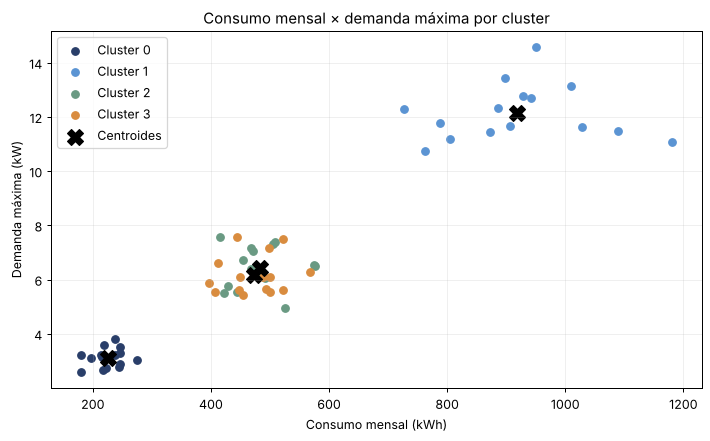

In [35]:
cores = ['#293E69', '#5B94D3', '#6A9A83', '#D98C3F']
plt.figure(figsize=(8, 5))
for cl in range(k_proposto):
    g = resultado_proposto[resultado_proposto['cluster'] == cl]
    plt.scatter(g['consumo_mensal_kwh'], g['demanda_maxima_kw'], color=cores[cl], label=f'Cluster {cl}')
plt.scatter(centroides_proposto['consumo_mensal_kwh'], centroides_proposto['demanda_maxima_kw'],
            marker='X', s=160, color='black', label='Centroides')
plt.xlabel('Consumo mensal (kWh)')
plt.ylabel('Demanda máxima (kW)')
plt.title('Consumo mensal × demanda máxima por cluster')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('imagens/consumo_x_demanda.png', dpi=120)
plt.show()

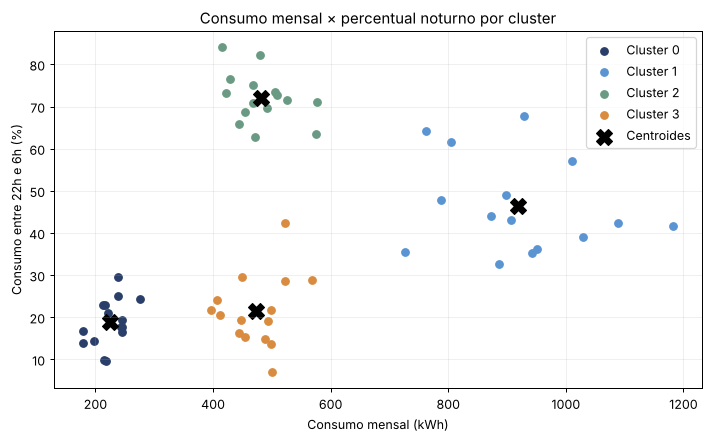

In [36]:
plt.figure(figsize=(8, 5))
for cl in range(k_proposto):
    g = resultado_proposto[resultado_proposto['cluster'] == cl]
    plt.scatter(g['consumo_mensal_kwh'], g['consumo_noturno_pct'], color=cores[cl], label=f'Cluster {cl}')
plt.scatter(centroides_proposto['consumo_mensal_kwh'], centroides_proposto['consumo_noturno_pct'],
            marker='X', s=160, color='black', label='Centroides')
plt.xlabel('Consumo mensal (kWh)')
plt.ylabel('Consumo entre 22h e 6h (%)')
plt.title('Consumo mensal × percentual noturno por cluster')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('imagens/consumo_x_noturno.png', dpi=120)
plt.show()

In [37]:
resumo_proposto = resultado_proposto.groupby('cluster').agg(
    consumidores=('consumidor', 'count'),
    consumo_medio_kwh=('consumo_mensal_kwh', 'mean'),
    demanda_media_kw=('demanda_maxima_kw', 'mean'),
    noturno_medio_pct=('consumo_noturno_pct', 'mean'),
)
resumo_proposto.sort_values('consumo_medio_kwh').round(2)

,consumidores,consumo_medio_kwh,demanda_media_kw,noturno_medio_pct
cluster,,,,
0,15,224.89,3.12,18.80
3,15,473.42,6.18,21.51
2,15,482.28,6.44,72.09
1,15,918.22,12.15,46.46


In [38]:
# Evidência para a questão 2: consumidores com consumo e demanda parecidos, mas horários diferentes
resultado_proposto[resultado_proposto['consumidor'].isin(['UC037', 'UC016', 'UC012', 'UC043'])]

,consumidor,consumo_mensal_kwh,demanda_maxima_kw,consumo_noturno_pct,cluster
11,UC012,500.72,5.56,7.08,3
15,UC016,491.68,6.06,69.71,2
36,UC037,493.39,5.67,19.09,3
42,UC043,525.42,4.96,71.66,2


### 2.7. Analisar os resultados
1. Descreva cada grupo usando as médias, evitando apenas repetir os números dos clusters.
2. Há consumidores com consumo e demanda semelhantes, mas percentuais noturnos diferentes? Mostre uma evidência.
3. Qual informação seria perdida se o percentual noturno fosse retirado da análise?
4. Proponha uma ação de acompanhamento para dois perfis, relacionando a proposta aos dados.
5. Explique por que os grupos não comprovam, sozinhos, eficiência energética, desperdício ou tipo de estabelecimento.

**Respostas:**

**1. Descrição dos grupos (médias nas unidades originais):**

| Cluster | Consumidores | Consumo médio | Demanda média | % noturno | Perfil |
|---:|---:|---:|---:|---:|---|
| 0 | 15 | ≈ 225 kWh | ≈ 3,1 kW | ≈ 19% | **Baixo consumo, uso diurno**: gastam pouca energia, com picos baixos, e concentram o uso durante o dia. |
| 3 | 15 | ≈ 473 kWh | ≈ 6,2 kW | ≈ 22% | **Consumo intermediário, uso diurno**: consomem cerca do dobro do grupo anterior, mas também usam a energia principalmente de dia. |
| 2 | 15 | ≈ 482 kWh | ≈ 6,4 kW | ≈ 72% | **Consumo intermediário, uso noturno**: mesmo nível de consumo e demanda do grupo anterior, porém cerca de 72% da energia é usada entre 22h e 6h. |
| 1 | 15 | ≈ 918 kWh | ≈ 12,2 kW | ≈ 47% | **Alto consumo e alta demanda**: consomem cerca de 4 vezes mais que o grupo de baixo consumo, com uso distribuído entre dia e noite. |

**2. Consumidores semelhantes em consumo e demanda, mas com horários diferentes:** sim. Os clusters 3 e 2 têm médias quase iguais de consumo (≈ 473 x ≈ 482 kWh) e de demanda (≈ 6,2 x ≈ 6,4 kW), mas percentuais noturnos muito diferentes (≈ 22% x ≈ 72%). Um exemplo individual: **UC037** (493,4 kWh; 5,67 kW; 19,1% noturno) e **UC016** (491,7 kWh; 6,06 kW; 69,7% noturno) ficaram em grupos diferentes. O mesmo acontece com UC012 (500,7 kWh; 7,1%) e UC043 (525,4 kWh; 71,7%).

**3. O que se perderia sem o percentual noturno:** os clusters 2 e 3 se fundiriam num só grupo de "consumo intermediário", porque se diferenciam quase só pelo horário de uso. A empresa perderia a informação sobre **quando** a energia é consumida, que é essencial para tarifas por horário, para planejar a carga da rede e para identificar quem já usa energia fora do horário de pico.

**4. Ações de acompanhamento:**
- **Alto consumo e alta demanda (cluster 1):** acompanhamento prioritário da demanda máxima (≈ 12 kW, o dobro dos grupos intermediários). Por exemplo, orientar a distribuir o uso de equipamentos potentes ao longo do dia para reduzir os picos, e avaliar a modalidade tarifária mais adequada.
- **Consumo intermediário com uso noturno (cluster 2):** como ≈ 72% do consumo já está entre 22h e 6h, esse grupo é candidato natural a tarifas com preço diferenciado por horário (como a Tarifa Branca). Ofertas desse tipo podem ser direcionadas a ele, e o grupo pode servir de referência para incentivar o deslocamento de carga em outros perfis.

**5. Por que os grupos não comprovam eficiência, desperdício ou tipo de estabelecimento:** o K-Means só agrupa consumidores **parecidos nas três medidas usadas**. Ele não sabe quais equipamentos existem, quantas pessoas há na unidade, qual a área, a atividade ou se o consumo é necessário. Um consumo alto pode ser totalmente justificado (uma padaria, por exemplo), e um uso noturno pode ser de uma residência ou de um comércio 24h. Além disso, os números dos clusters são só rótulos e a base é simulada. Os grupos indicam **hipóteses** a investigar, não conclusões.

## 3. Exercício no Orange Data Mining

Use a base **`consumidores_energia_proposto.csv`** para identificar os perfis sem escrever o algoritmo em Python. Esta atividade pode ser feita de forma independente do exercício 2. Depois, se você concluir as duas, poderá comparar os resultados.

O arquivo CSV acompanha este notebook. Se precisar recriá-lo, execute a importação das bibliotecas em 1.1, o carregamento da base em 2.1 e a célula abaixo. Ela exporta somente os dados de entrada, sem clusters.

In [39]:
df_proposto.to_csv('consumidores_energia_proposto.csv', index=False)
print('Arquivo consumidores_energia_proposto.csv criado na pasta de execução.')

Arquivo consumidores_energia_proposto.csv criado na pasta de execução.


No Colab, abra a aba **Arquivos**, atualize a lista, localize o CSV e use a opção **Fazer download**. No Jupyter, ele fica na pasta de execução.

### 3.1. Importar e selecionar as colunas
1. Adicione **File** e abra o CSV. O separador é vírgula e o separador decimal é ponto.
2. Confira as 60 linhas e as quatro colunas em **Data Table**. Se uma entrada numérica aparecer como texto ou categoria, ajuste seu tipo para numérico contínuo na importação.
3. Ligue **File → Select Columns**. Coloque os três atributos numéricos em **Features**; coloque `consumidor` em **Meta Attributes** e deixe **Target** vazio.

### 3.2. Agrupar e comparar k
1. Ligue **Select Columns → k-Means**.
2. Ative **Normalize columns**. Essa opção centraliza as entradas pela média e divide pelo desvio padrão, como a padronização usada no Python.
3. Selecione **k-Means++** e ajuste **Re-runs** para 10.
4. Na opção de intervalo **From ... to ...**, teste **2 a 8 clusters**. Registre os valores de Silhouette Score exibidos pelo próprio widget.
5. Escolha uma configuração e justifique-a pelo Silhouette Score e pela interpretação dos grupos. Se necessário, use **Fixed** para fixar o k escolhido.

Neste roteiro, a comparação de k no Orange usa o Silhouette Score do widget k-Means. A curva do cotovelo é construída na atividade Python.

| k | Silhouette Score no Orange |
| --- | --- |
| 2 | Preencher |
| 3 | Preencher |
| 4 | Preencher |
| 5 | Preencher |
| 6 | Preencher |
| 7 | Preencher |
| 8 | Preencher |

### 3.3. Visualizar e interpretar
Conecte a saída **Data** de k-Means, em conexões separadas, a:

- **Data Table:** veja qual cluster foi atribuído a cada consumidor.
- **Scatter Plot:** selecione consumo no eixo X, demanda no eixo Y e `Cluster` em **Color**. Faça outro gráfico com consumo e percentual noturno.
- **Box Plot:** escolha cada entrada e selecione `Cluster` em **Subgroups**. Compare as médias, medianas e a dispersão dos grupos nas unidades originais.
- **Save Data:** exporte a base com os clusters, mantendo os metadados no arquivo.

Salve também o fluxo em formato **`.ows`**. Os nomes de cluster do Orange podem ser C1, C2 etc.; compare os perfis pelas características, não pelo número do rótulo.

### 3.4. Questões da atividade
1. Qual k foi escolhido? Quais valores de Silhouette Score apoiam a escolha?
2. Descreva os perfis encontrados usando consumo, demanda e percentual noturno.
3. Como o percentual noturno ajuda a distinguir consumidores?
4. Proponha duas ações de acompanhamento apoiadas nas características dos grupos.
5. **Se você também fez o exercício 2:** compare k, Silhouette Score e perfis nas duas ferramentas. Pequenas diferenças podem ocorrer pelas inicializações do algoritmo. Uma troca nos nomes dos clusters, por si só, não indica uma solução diferente.

**Respostas e registros do Orange:**

> ⚠️ Preencha a tabela com os valores que **o seu Orange** mostrar no widget k-Means (Normalize columns ativado, k-Means++, Re-runs = 10, From 2 to 8). Os valores do Python servem como referência: os do Orange devem ser parecidos, mas podem variar um pouco por causa das inicializações.

| k | Silhouette Score no Orange | Referência no Python |
| --- | --- | --- |
| 2 | _preencher_ | 0,526 |
| 3 | _preencher_ | 0,648 |
| 4 | _preencher_ | 0,667 |
| 5 | _preencher_ | 0,586 |
| 6 | _preencher_ | 0,594 |
| 7 | _preencher_ | 0,533 |
| 8 | _preencher_ | 0,531 |

**1. k escolhido:** k = 4, por ter o maior Silhouette Score da tabela (confirmar com os valores do Orange).

**2. Perfis:** os mesmos quatro do exercício 2: baixo consumo e uso diurno (≈ 225 kWh, ≈ 3 kW, ≈ 19% noturno); intermediário diurno (≈ 473 kWh, ≈ 6 kW, ≈ 22%); intermediário noturno (≈ 482 kWh, ≈ 6 kW, ≈ 72%); alto consumo e alta demanda (≈ 918 kWh, ≈ 12 kW, ≈ 47%). Confira no Box Plot, que mostra as medianas por cluster.

**3. Papel do percentual noturno:** no Scatter Plot de consumo × demanda, os dois grupos intermediários aparecem sobrepostos. No gráfico de consumo × percentual noturno eles se separam claramente (≈ 20% x ≈ 70%). É essa variável que distingue os dois perfis.

**4. Ações:** (a) monitorar e orientar o grupo de alta demanda para reduzir picos; (b) oferecer tarifa diferenciada por horário ao grupo com uso predominantemente noturno.

**5. Comparação Python × Orange:** _preencher após rodar o Orange_. Os nomes no Orange (C1 a C4) não correspondem aos números do Python (0 a 3). Compare pelos perfis (médias), não pelos rótulos.

## Entrega

Disponibilize um **link para um repositório do GitHub** contendo:

- O notebook com o exercício proposto implementado, resultados visíveis e respostas.
- O CSV de entrada e o CSV exportado pelo Orange com os clusters.
- O fluxo do Orange em `.ows` e imagens dos gráficos e da comparação de Silhouette Score.
- Um `README.md` breve com a escolha de k, descrição dos perfis e ações sugeridas.

## Referências

- [Scikit-learn — KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
- [Scikit-learn — StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
- [Scikit-learn — silhouette_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)
- [Orange — k-Means](https://orangedatamining.com/widget-catalog/unsupervised/kmeans/)
- [Orange — Select Columns](https://orangedatamining.com/widget-catalog/transform/selectcolumns/)
- [Orange — Scatter Plot](https://orangedatamining.com/widget-catalog/visualize/scatterplot/)
- [Orange — Box Plot](https://orangedatamining.com/widget-catalog/visualize/boxplot/)